**Nombre:** Cantidad de ambulancias, camas y salas por departamento, año y naturaleza jurídica para servicios habilitados.

**Fuente de los Datos:** datos.gov.co

**Descripción general:** Este conjunto de datos contiene el registro oficial y detallado de la infraestructura física y de transporte asistencial con la que cuentan las instituciones prestadoras de servicios de salud en Colombia. Los datos fueron recopilados de manera oficial por el Ministerio de Salud y Protección Social a través del Registro Especial de Prestadores de Servicios de Salud (REPS), el cual consolida la información que cada hospital y clínica debe reportar obligatoriamente para mantener sus servicios habilitados.

**Número de filas y columnas:** El dataset original está compuesto por un total de 378 filas (registros) y 22 columnas (variables).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/Cantidad_de_ambulancias,_camas_y_salas_(consideradas_trazadoras)_por_departamento,_año_y_naturaleza_jurídica_para_servicios_habilitados_20260520.csv")
df

,Departamento,Año,Naturaleza jurídica,AMBULANCIAS Básica,AMBULANCIAS Medicalizada,CAMAS Adultos,CAMAS Cuidado Agudo Mental,CAMAS Cuidado Intensivo Adulto,CAMAS Cuidado Intensivo Neonatal,CAMAS Cuidado Intensivo Pediátrico,...,CAMAS Cuidado Intermedio Neonatal,CAMAS Cuidado Intermedio Pediátrico,CAMAS Farmacodependencia,CAMAS Obstetricia,CAMAS Pediátrica,CAMAS Psiquiatría,CAMAS Unidad de Quemados Adulto,CAMAS Unidad de Quemados Pediátrico,SALAS Partos,SALAS Quirófano
0,Amazonas,2017.0,Privada,0,0,41,0,0,0,0,...,0,0,0,2,7,0,0,0,0,1
1,Amazonas,2017.0,Pública,3,0,27,0,0,0,0,...,0,3,0,21,28,0,0,0,4,2
2,Amazonas,2018.0,Privada,0,0,41,0,0,0,0,...,0,0,30,2,7,0,0,0,0,1
3,Amazonas,2018.0,Pública,3,0,27,0,0,0,0,...,0,3,0,21,28,0,0,0,8,2
4,Amazonas,2019.0,Privada,0,0,41,0,0,0,0,...,0,0,30,2,7,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,Valle del cauca,2022.0,Pública,133,9,491,0,45,0,0,...,0,0,0,0,168,0,0,0,44,0
374,Vaupés,2022.0,Privada,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
375,Vaupés,2022.0,Pública,2,0,14,0,0,0,0,...,0,0,0,1,8,0,0,0,3,0
376,Vichada,2022.0,Privada,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
#visualizamos las primeras 5 filas
df.head()

,Departamento,Año,Naturaleza jurídica,AMBULANCIAS Básica,AMBULANCIAS Medicalizada,CAMAS Adultos,CAMAS Cuidado Agudo Mental,CAMAS Cuidado Intensivo Adulto,CAMAS Cuidado Intensivo Neonatal,CAMAS Cuidado Intensivo Pediátrico,...,CAMAS Cuidado Intermedio Neonatal,CAMAS Cuidado Intermedio Pediátrico,CAMAS Farmacodependencia,CAMAS Obstetricia,CAMAS Pediátrica,CAMAS Psiquiatría,CAMAS Unidad de Quemados Adulto,CAMAS Unidad de Quemados Pediátrico,SALAS Partos,SALAS Quirófano
0,Amazonas,2017.0,Privada,0,0,41,0,0,0,0,...,0,0,0,2,7,0,0,0,0,1
1,Amazonas,2017.0,Pública,3,0,27,0,0,0,0,...,0,3,0,21,28,0,0,0,4,2
2,Amazonas,2018.0,Privada,0,0,41,0,0,0,0,...,0,0,30,2,7,0,0,0,0,1
3,Amazonas,2018.0,Pública,3,0,27,0,0,0,0,...,0,3,0,21,28,0,0,0,8,2
4,Amazonas,2019.0,Privada,0,0,41,0,0,0,0,...,0,0,30,2,7,0,0,0,1,1


In [8]:
#Verificamos filas y columnas
df.shape

(378, 22)

In [9]:
#Visualizamos el tipo de datos
df.dtypes

,0
Departamento,object
Año,float64
Naturaleza jurídica,object
AMBULANCIAS Básica,object
AMBULANCIAS Medicalizada,object
CAMAS Adultos,object
CAMAS Cuidado Agudo Mental,object
CAMAS Cuidado Intensivo Adulto,object
CAMAS Cuidado Intensivo Neonatal,object
CAMAS Cuidado Intensivo Pediátrico,object


In [10]:
#Verificamos los valores nulos
df.isnull().sum()

,0
Departamento,0
Año,1
Naturaleza jurídica,1
AMBULANCIAS Básica,0
AMBULANCIAS Medicalizada,0
CAMAS Adultos,0
CAMAS Cuidado Agudo Mental,0
CAMAS Cuidado Intensivo Adulto,0
CAMAS Cuidado Intensivo Neonatal,0
CAMAS Cuidado Intensivo Pediátrico,0


In [11]:
#Identificamos los duplicados
df.duplicated().sum()

np.int64(0)

In [12]:
#Eliminamos los duplicados (Aunque en este caso no hay)
df = df.drop_duplicates()

In [13]:
#Seleccionamos las columnas numericas con nulos
columnas_num_con_nulos = df.select_dtypes(include=[np.number]).columns

In [14]:
#Rellenamos los valores faltantes con la media (Aunque en este caso no aplica)
for col in columnas_num_con_nulos:
    df[col] = df[col].fillna(df[col].median())

In [15]:
#Ahora las variables de texto
columnas_obj_con_nulos = df.select_dtypes(include=['object']).columns

In [16]:
#Aplicamos la moda a las columnas de texto
for col in columnas_obj_con_nulos:
    df[col] = df[col].fillna(df[col].mode()[0])

In [32]:
import pandas as pd

df = pd.read_csv('/content/Cantidad_de_ambulancias,_camas_y_salas_(consideradas_trazadoras)_por_departamento,_año_y_naturaleza_jurídica_para_servicios_habilitados_20260520.csv')

#filtramos en el año mas reciente
df = df[df['Año'] == 2022]
df = df.drop(columns=['Año'])

#Limpieza de texto: Pasamos a mayúsculas y quitamos espacios invisibles en los extremos
df['Departamento'] = df['Departamento'].astype(str).str.upper().str.strip()

#lista oficial de departamentos legítimos de Colombia (para descartar ciudades)
departamentos_colombia = [
    'AMAZONAS', 'ANTIOQUIA', 'ARAUCA', 'ATLANTICO', 'BOLIVAR', 'BOYACA', 'CALDAS',
    'CAQUETA', 'CASANARE', 'CAUCA', 'CESAR', 'CHOCO', 'CORDOBA', 'CUNDINAMARCA',
    'GUAINIA', 'GUAVIARE', 'HUILA', 'LA GUAJIRA', 'MAGDALENA', 'META', 'NARINO',
    'NORTE DE SANTANDER', 'PUTUMAYO', 'QUINDIO', 'RISARALDA', 'SAN ANDRES',
    'SANTANDER', 'SUCRE', 'TOLIMA', 'VALLE DEL CAUCA', 'VAUPES', 'VICHADA', 'BOGOTA'
]

#FILTRADO CRÍTICO: Dejar en el DataFrame SOLO las filas que pertenezcan a la lista oficial
df = df[df['Departamento'].isin(departamentos_colombia)]
df

,Departamento,Naturaleza jurídica,AMBULANCIAS Básica,AMBULANCIAS Medicalizada,CAMAS Adultos,CAMAS Cuidado Agudo Mental,CAMAS Cuidado Intensivo Adulto,CAMAS Cuidado Intensivo Neonatal,CAMAS Cuidado Intensivo Pediátrico,CAMAS Cuidado Intermedio Adulto,...,CAMAS Cuidado Intermedio Neonatal,CAMAS Cuidado Intermedio Pediátrico,CAMAS Farmacodependencia,CAMAS Obstetricia,CAMAS Pediátrica,CAMAS Psiquiatría,CAMAS Unidad de Quemados Adulto,CAMAS Unidad de Quemados Pediátrico,SALAS Partos,SALAS Quirófano
287,AMAZONAS,Privada,1,0,29,0,0,0,0,0,...,0,0,0,0,2,0,0,0,1,0
288,AMAZONAS,Pública,0,0,71,0,0,0,0,18,...,0,2,0,0,30,0,0,0,7,2
289,ANTIOQUIA,Mixta,3,0,496,0,0,0,0,0,...,0,0,0,0,17,0,0,0,1,0
290,ANTIOQUIA,Privada,259,113,"3,718",0,121,20,14,111,...,17,5,20,47,534,0,0,0,24,70
291,ANTIOQUIA,Pública,301,15,"2,224",0,62,14,5,18,...,34,3,0,65,475,0,0,0,129,17
292,ARAUCA,Privada,20,11,7,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
293,ARAUCA,Pública,28,5,170,0,0,0,0,0,...,0,0,0,0,61,0,0,0,7,0
308,CALDAS,Mixta,0,0,111,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
309,CALDAS,Privada,50,17,530,0,0,0,0,0,...,0,0,0,0,104,0,0,0,1,1
310,CALDAS,Pública,108,13,452,0,0,0,0,0,...,0,0,0,0,93,0,0,0,35,0


In [33]:
#Ahora eliminamos la columna año porque ya no la necesitamos ya que la filtramos
df = df.drop(columns=['Año'], errors='ignore')

Se tomó la decisión de filtrar la base de datos para conservar únicamente los registros del año 2022, ya que el objetivo es evaluar el estado actual y más reciente de la infraestructura hospitalaria. Al aplicar este filtro, la columna 'Año' se vuelve constante y redundante para el análisis exploratorio, por lo cual se procede a su eliminación

In [34]:
df

,Departamento,Naturaleza jurídica,AMBULANCIAS Básica,AMBULANCIAS Medicalizada,CAMAS Adultos,CAMAS Cuidado Agudo Mental,CAMAS Cuidado Intensivo Adulto,CAMAS Cuidado Intensivo Neonatal,CAMAS Cuidado Intensivo Pediátrico,CAMAS Cuidado Intermedio Adulto,...,CAMAS Cuidado Intermedio Neonatal,CAMAS Cuidado Intermedio Pediátrico,CAMAS Farmacodependencia,CAMAS Obstetricia,CAMAS Pediátrica,CAMAS Psiquiatría,CAMAS Unidad de Quemados Adulto,CAMAS Unidad de Quemados Pediátrico,SALAS Partos,SALAS Quirófano
287,AMAZONAS,Privada,1,0,29,0,0,0,0,0,...,0,0,0,0,2,0,0,0,1,0
288,AMAZONAS,Pública,0,0,71,0,0,0,0,18,...,0,2,0,0,30,0,0,0,7,2
289,ANTIOQUIA,Mixta,3,0,496,0,0,0,0,0,...,0,0,0,0,17,0,0,0,1,0
290,ANTIOQUIA,Privada,259,113,"3,718",0,121,20,14,111,...,17,5,20,47,534,0,0,0,24,70
291,ANTIOQUIA,Pública,301,15,"2,224",0,62,14,5,18,...,34,3,0,65,475,0,0,0,129,17
292,ARAUCA,Privada,20,11,7,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
293,ARAUCA,Pública,28,5,170,0,0,0,0,0,...,0,0,0,0,61,0,0,0,7,0
308,CALDAS,Mixta,0,0,111,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
309,CALDAS,Privada,50,17,530,0,0,0,0,0,...,0,0,0,0,104,0,0,0,1,1
310,CALDAS,Pública,108,13,452,0,0,0,0,0,...,0,0,0,0,93,0,0,0,35,0


In [35]:
#Generamos la tabla resumen
tabla_resumen = df.describe()
print(tabla_resumen)

       CAMAS Cuidado Intermedio Mental  CAMAS Unidad de Quemados Adulto  \
count                             51.0                             51.0   
mean                               0.0                              0.0   
std                                0.0                              0.0   
min                                0.0                              0.0   
25%                                0.0                              0.0   
50%                                0.0                              0.0   
75%                                0.0                              0.0   
max                                0.0                              0.0   

       CAMAS Unidad de Quemados Pediátrico  
count                                 51.0  
mean                                   0.0  
std                                    0.0  
min                                    0.0  
25%                                    0.0  
50%                                    0.0  
75%      

In [36]:
columnas_a_sumar = [col for col in df.columns if any(x in col for x in ['CAMAS', 'AMBULANCIAS', 'SALAS'])]
print("columnas encontradas sumar:")
print(columnas_a_sumar)

columnas encontradas sumar:
['AMBULANCIAS Básica', 'AMBULANCIAS Medicalizada', 'CAMAS Adultos', 'CAMAS Cuidado Agudo Mental', 'CAMAS Cuidado Intensivo Adulto', 'CAMAS Cuidado Intensivo Neonatal', 'CAMAS Cuidado Intensivo Pediátrico', 'CAMAS Cuidado Intermedio Adulto', 'CAMAS Cuidado Intermedio Mental', 'CAMAS Cuidado Intermedio Neonatal', 'CAMAS Cuidado Intermedio Pediátrico', 'CAMAS Farmacodependencia', 'CAMAS Obstetricia', 'CAMAS Pediátrica', 'CAMAS Psiquiatría', 'CAMAS Unidad de Quemados Adulto', 'CAMAS Unidad de Quemados Pediátrico', 'SALAS Partos', 'SALAS Quirófano']


In [37]:
for col in columnas_a_sumar:
 df[col] = pd.to_numeric(df[col], errors='coerce')
df[columnas_a_sumar] = df[columnas_a_sumar].fillna(0)
df['CANTIDAD DE EQUIPOS'] = df[columnas_a_sumar].sum(axis=1)
print(df[['CANTIDAD DE EQUIPOS']].head())

     CANTIDAD DE EQUIPOS
287                 33.0
288                130.0
289                517.0
290               1355.0
291               1138.0


**Distribución Total de Camas de Cuidado Intensivo (UCI) por Departamento**

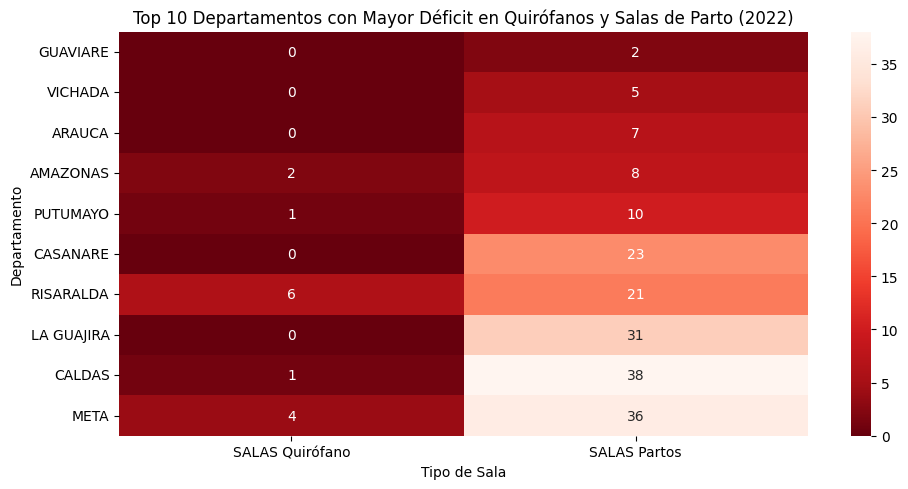

In [44]:

plt.figure(figsize=(10, 5))
sns.heatmap(top_deficit[['SALAS Quirófano', 'SALAS Partos']], annot=True, cmap='Reds_r', fmt='g', cbar=True)
plt.title('Top 10 Departamentos con Mayor Déficit en Quirófanos y Salas de Parto (2022)')
plt.xlabel('Tipo de Sala')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

 **Interpretación:**

 Se evidencia que los departamentos periféricos como Vichada presenta cifras críticamente bajas (cercanas a cero) en infraestructura quirúrgica y de partos, confirmando un severo déficit tecnológico regional.

**Distribución de Camas UCI Adulto por Departamento y ciudades**

/tmp/ipykernel_1039/2699550003.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=uci_por_dep.values, y=uci_por_dep.index, palette="Blues_r")


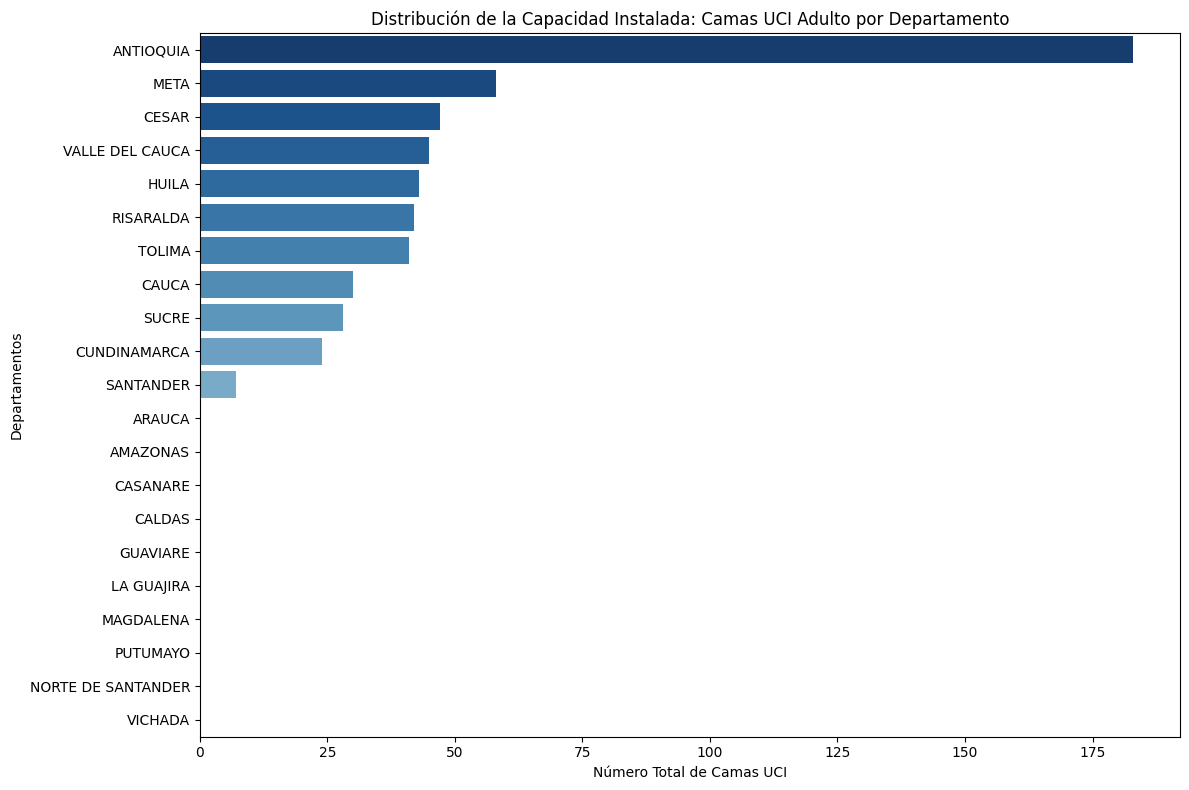

In [39]:
uci_por_dep = df.groupby('Departamento')['CAMAS Cuidado Intensivo Adulto'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=uci_por_dep.values, y=uci_por_dep.index, palette="Blues_r")
plt.title('Distribución de la Capacidad Instalada: Camas UCI Adulto por Departamento')
plt.xlabel('Número Total de Camas UCI')
plt.ylabel('Departamentos')
plt.tight_layout()
plt.show()

**Interpretación**

El gráfico refleja un modelo de salud altamente centralizado limitando la respuesta local en el resto de los departamentos.

**Comparativa de Ambulancias Básicas vs. Medicalizada**

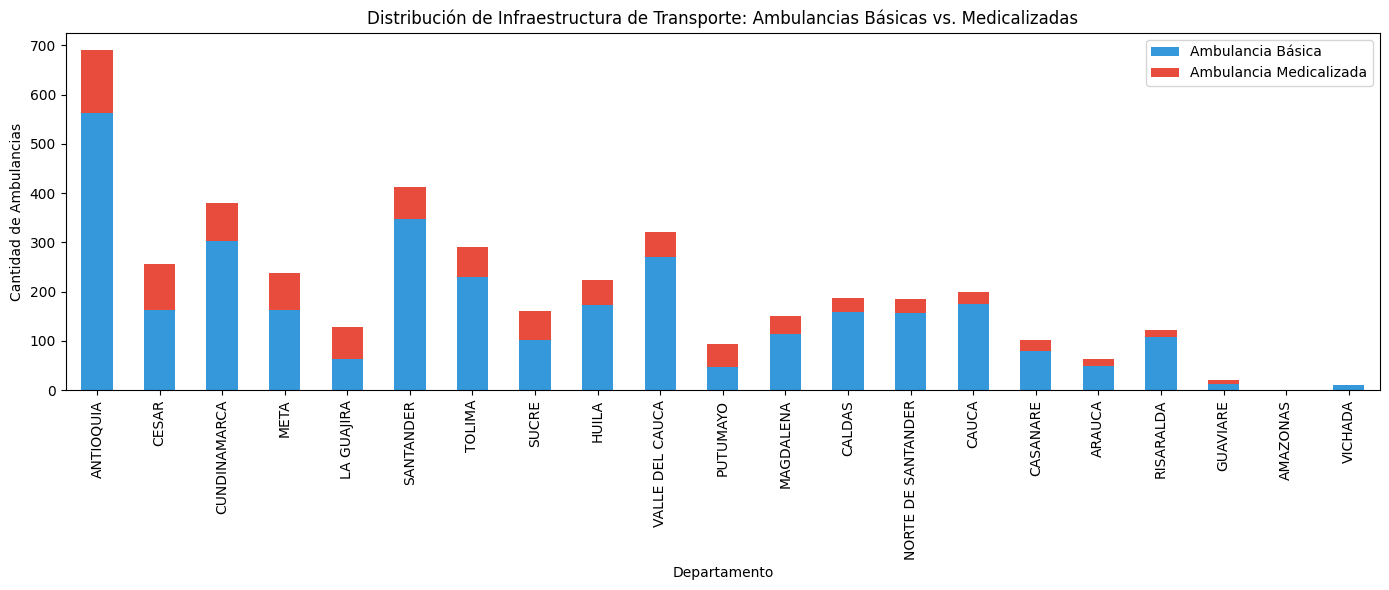

In [40]:
ambulancias = df.groupby('Departamento')[['AMBULANCIAS Básica', 'AMBULANCIAS Medicalizada']].sum().sort_values(by='AMBULANCIAS Medicalizada', ascending=False)
ambulancias.plot(kind='bar', stacked=True, figsize=(14, 6), color=['#3498db', '#e74c3c'])
plt.title('Distribución de Infraestructura de Transporte: Ambulancias Básicas vs. Medicalizadas')
plt.xlabel('Departamento')
plt.ylabel('Cantidad de Ambulancias')
plt.xticks(rotation=90)
plt.legend(['Ambulancia Básica', 'Ambulancia Medicalizada'])
plt.tight_layout()
plt.show()

**Interpretación:**

 Se observa que aunque la flota de transporte terrestre es numéricamente alta en varias regiones, predomina el transporte básico. Las ambulancias medicalizadas son escasas en los departamentos con mayor déficit hospitalario.

**Capacidad de Camas Hospitalarias según la Naturaleza Jurídica**

/tmp/ipykernel_1039/1459736506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=camas_naturaleza, x='Naturaleza jurídica', y='CAMAS Adultos', palette='Set2')


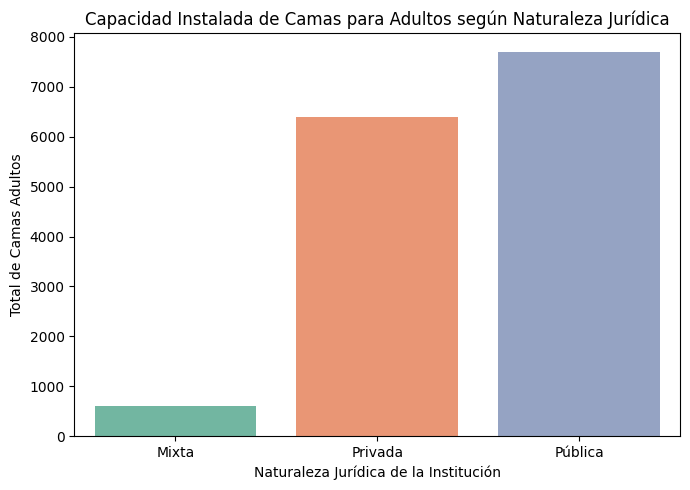

In [41]:
camas_naturaleza = df.groupby('Naturaleza jurídica')['CAMAS Adultos'].sum().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(data=camas_naturaleza, x='Naturaleza jurídica', y='CAMAS Adultos', palette='Set2')
plt.title('Capacidad Instalada de Camas para Adultos según Naturaleza Jurídica')
plt.xlabel('Naturaleza Jurídica de la Institución')
plt.ylabel('Total de Camas Adultos')
plt.tight_layout()

**Interpretación:**

 Permite contrastar directamente qué sector sostiene la carga física del sistema. Demuestra que el sector privado lidera con una diferencia muy alta la disponibilidad de camas para adultos en el país frente a la red pública hospitalaria.

**Relación y equilibrio entre el número de Quirófanos y las Camas UCI, diferenciado por si el hospital es público o privado.**

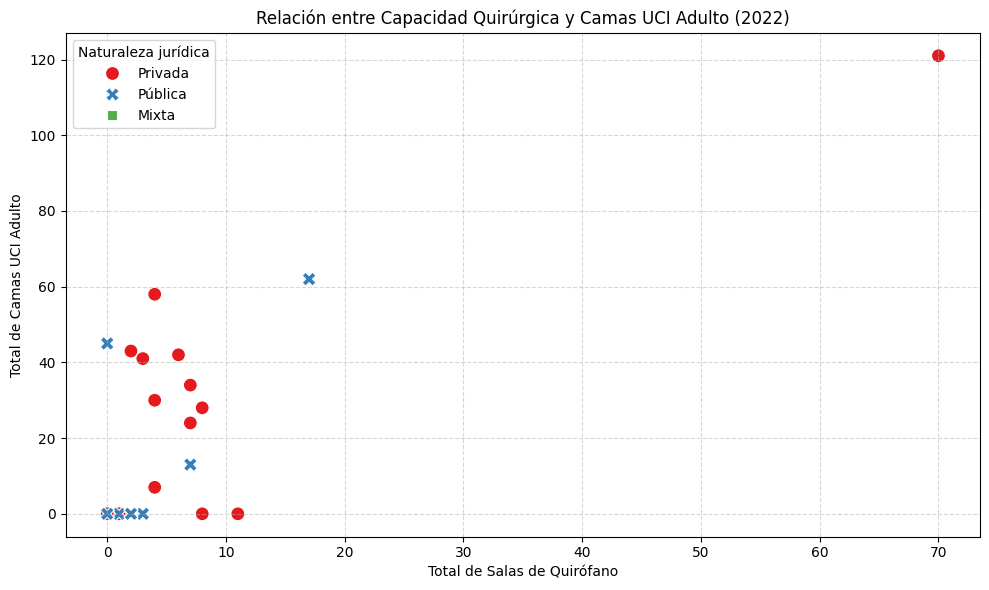

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='SALAS Quirófano', y='CAMAS Cuidado Intensivo Adulto',
                hue='Naturaleza jurídica', style='Naturaleza jurídica', s=100, palette='Set1')

plt.title('Relación entre Capacidad Quirúrgica y Camas UCI Adulto (2022)')
plt.xlabel('Total de Salas de Quirófano')
plt.ylabel('Total de Camas UCI Adulto')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretación:**

Seconfirma una correlación lineal positiva donde a mayor número de quirófanos se requiere mayor soporte de camas UCI. Los puntos rojos (privados) e industriales muestran un mayor equilibrio tecnológico que la red pública.

**Conclusiones más importantes extraídas de los datos**

**Centralización crítica de la infraestructura de alta complejidad:** Los datos demuestran una gigantesca disparidad regional. Departamentos centrales y con grandes capitales concentran la gran mayoría de las camas UCI de adultos y quirófanos del país, dejando rezagados a los territorios periféricos.

**Brecha en el transporte asistencial crítico:** Aunque muchos departamentos cuentan con una flota de ambulancias numéricamente alta, la gran mayoría de estas son de tipo básico. La disponibilidad de ambulancias medicalizadas (vitales para el soporte de vida en trayectos largos hacia centros de mayor complejidad) es alarmantemente baja en las regiones con mayor déficit hospitalario.

**Predominio del sector privado en la capacidad instalada:** El análisis de la naturaleza jurídica de las instituciones evidencia que el mayor volumen de camas para adultos en el país recae sobre el sector privado, lo que plantea un reto de cobertura y accesibilidad económica para las poblaciones más vulnerables que dependen del sistema público.

**¿Se logró responder la pregunta?**

Lo que se logró:
A través de los datos del año 2022, se mapeó con precisión matemática el estado actual de la capacidad instalada nacional y se identificaron con claridad los 10 departamentos que presentan el mayor déficit de infraestructura crítica (quirófanos, salas de parto y camas de alta complejidad).

**Limitaciones del análisis**

**Calidad y actualización de los datos:** Al tratarse de un registro administrativo de habilitación (REPS), la base de datos refleja la capacidad que las instituciones reportan formalmente, pero puede existir un desfase temporal entre el equipamiento que está habilitado en papel y los equipos biomédicos que realmente se encuentran operativos y con mantenimiento vigente en los hospitales.

**Ausencia de variables de estado tecnológico:** El dataset cuantifica la infraestructura (indica "cuántas" salas o camas hay), pero no detalla el estado tecnológico real, la obsolescencia de los equipos de soporte, ni el nivel de dotación biomédica interna de dichos espacios.

**Posibles pasos siguientes si el proyecto continuara**

**Integración de datos demográficos y epidemiológicos:** Cruzar la base de datos de infraestructura con los datos de población del DANE y las tasas de morbilidad por departamento para calcular la tasa de disponibilidad de equipos médicos por habitante y contrastarla con las necesidades de salud locales.

**Inclusión de georreferenciación avanzada:** Implementar librerías de mapas (como Folium o Geopandas) para generar mapas coroplépticos de Colombia que permitan visualizar el déficit tecnológico de forma espacial y por corredores viales de remisión de pacientes.

**Análisis predictivo de requerimientos:** Desarrollar modelos de aprendizaje automático (Machine Learning) basados en las tendencias de años anteriores para proyectar en qué regiones se acentuará el déficit tecnológico a mediano plazo, sirviendo como herramienta de planeación para la inversión en tecnologías en salud.